# 1. Introducción y Objetivos
**Autor:** Franco Robotti  
**Objetivo:** El presente análisis tiene como propósito entender la estructura, las distribuciones y las relaciones básicas del dataset del *customer journey* de Paigo

# Diccionario de Datos

## Resumen

| Tabla | Grano | Campos clave |
|---|---|---|
| `clientes` | 1 fila = 1 cliente | `id_cliente` (PK), `segmento`, `canal_adquisicion`, `pais`, `tiene_producto_activo`, `nps_score` |
| `productos` | 1 fila = 1 producto | `id_producto` (PK), `categoria`, `tasa_nominal_anual`, `monto_min/max`, `activo` |
| `reviews_stores` | 1 fila = 1 review de app | `id_review` (PK), `id_cliente` (FK), `id_producto` (FK), `store`, `version_app`, `rating`, `respondida` |
| `bot_chats` | 1 fila = 1 conversación | `id_chat` (PK), `id_cliente` (FK), `id_producto` (FK), `canal`, `intent_primario`, `resolucion`, `csat_score`, `escalado_humano` |

> `nps_score` (0–10) y `csat_score` (1–5) admiten nulls por diseño (cliente que no respondió la encuesta).

### `clientes.xlsx`

| Campo | Tipo | Rol | Descripción |
| :--- | :--- | :--- | :--- |
| **id_cliente** | INTEGER | PK | Identificador único del cliente |
| **fecha_alta** | DATE | | Fecha de registro en la plataforma |
| **segmento** | STRING | | Nuevo / Recurrente / Premium / Inactivo |
| **canal_adquisicion** | STRING | | Canal por el que llegó: Organico, Referido, Paid Social, App Store, Alianza Comercial |
| **pais** | STRING | | País del cliente (UY, AR, PY) |
| **tiene_producto_active** | BOOLEAN | | True si tiene al menos un producto financiero activo |
| **nps_score** | FLOAT | | Net Promoter Score declarado (0–10). Null si no respondió la encuesta |



### `productos.xlsx`

| Campo | Tipo | Rol | Descripción |
| :--- | :--- | :--- | :--- |
| **id_producto** | INTEGER | PK | Identificador único del producto |
| **nombre_producto** | STRING | | Nombre comercial del producto |
| **categoria** | STRING | | Prestamo Personal / Credito Revolvente / BNPL / Adelanto / Microcrédito |
| **tasa_nominal_anual** | FLOAT | | TNA del producto (ej: 0.48 = 48%) |
| **plazo_max_meses** | INTEGER | | Plazo máximo en meses. Null para productos revolving |
| **monto_min** | INTEGER | | Monto mínimo otorgable en moneda local |
| **monto_max** | INTEGER | | Monto máximo otorgable en moneda local |
| **activo** | BOOLEAN | | True si el producto está vigente en el catálogo |



### `reviews_stores.xlsx`

| Campo | Tipo | Rol | Descripción |
| :--- | :--- | :--- | :--- |
| **id_review** | INTEGER | PK | Identificador único de la review |
| **id_cliente** | INTEGER | FK | Cliente que dejó la review |
| **id_producto** | INTEGER | FK | Producto sobre el que trata la review |
| **store** | STRING | | Google Play o App Store |
| **version_app** | STRING | | Versión de la app al momento de la review |
| **fecha_review** | DATE | | Fecha de publicación de la review |
| **rating** | INTEGER | | Puntuación de 1 a 5 estrellas |
| **comentario** | STRING | | Texto libre de la review (simplificado) |
| **util_votos** | INTEGER | | Cantidad de votos 'útil' recibidos por la review |
| **respondida** | BOOLEAN | | True si el equipo de la app respondió la review |



### `bot_chats.xlsx`

| Campo | Tipo | Rol | Descripción |
| :--- | :--- | :--- | :--- |
| **id_chat** | INTEGER | PK | Identificador único de la conversación |
| **id_cliente** | INTEGER | FK | Cliente que inició el chat |
| **id_producto** | FLOAT | FK | Producto relacionado con la consulta. Null si es genérico |
| **fecha_inicio** | DATE | | Fecha de inicio de la conversación |
| **canal** | STRING | | WhatsApp / App / Web / SMS |
| **intent_primario** | STRING | | Intencion detectada: consulta_saldo, solicitud_prestamo, reclamo_cobro, baja_producto, onboarding_dudas... |
| **duracion_segundos** | FLOAT | | Duración total de la conversación en segundos. Null si se cortó |
| **mensajes_enviados** | INTEGER | | Cantidad de mensajes enviados por el cliente en la sesión |
| **resolucion** | STRING | | Resuelto bot / Derivado humano / Abandono / Sin resolución |
| **csat_score** | FLOAT | | Customer Satisfaction Score (1–5). Null si el cliente no puntuó |
| **escalado_humano** | BOOLEAN | | True si la conversación fue escalada a un agente humano |

## 1. Configuración

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETA = "viridis"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(exist_ok=True)

def guardar(nombre):
    """Guarda la figura actual en FIG_DIR con buena resolución."""
    plt.savefig(FIG_DIR / f"{nombre}.png", dpi=200, bbox_inches="tight")

## 2. Ingesta y Validación de Datos

In [5]:
DATA_DIR = Path("../data/raw")
print("Cargando datos desde:", DATA_DIR.resolve())

productos = pd.read_excel(DATA_DIR / "productos.xlsx")
reviews_stores = pd.read_excel(DATA_DIR / "reviews_stores.xlsx")
bot_chats = pd.read_excel(DATA_DIR / "bot_chats.xlsx")
clientes = pd.read_excel(DATA_DIR / "clientes.xlsx")

for df, name in zip(
    [productos, reviews_stores, bot_chats, clientes],
    ["productos", "reviews_stores", "bot_chats", "clientes"],
):
     print(f"{name:16s} -> {df.shape[0]:>5} filas x {df.shape[1]} columnas")

Cargando datos desde: C:\Users\franc\Escritorio\Analista de Business Intelligence\data\raw
productos        ->     5 filas x 8 columnas
reviews_stores   ->  2200 filas x 10 columnas
bot_chats        ->  3000 filas x 11 columnas
clientes         ->  1500 filas x 7 columnas


## 3. Validación y normalización de tipos

In [6]:
for nombre, df in [("clientes", clientes), ("productos", productos), ("reviews_stores", reviews_stores), ("bot_chats", bot_chats)]:
    print("="*70)
    print(nombre)
    print("="*70)
    df.info()
    print()

clientes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_cliente             1500 non-null   int64         
 1   fecha_alta             1500 non-null   datetime64[ns]
 2   segmento               1500 non-null   object        
 3   canal_adquisicion      1500 non-null   object        
 4   pais                   1500 non-null   object        
 5   tiene_producto_activo  1500 non-null   bool          
 6   nps_score              1379 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 71.9+ KB

productos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_producto         5 non-null      int64  
 1   

In [7]:
def mostrar_descripcion(df, nombre):
    print(f"Descripción de la tabla {nombre}:")
    display(df.describe())

mostrar_descripcion(clientes, "clientes")
mostrar_descripcion(productos, "productos")
mostrar_descripcion(reviews_stores, "reviews_stores")
mostrar_descripcion(bot_chats, "bot_chats")

Descripción de la tabla clientes:


,id_cliente,fecha_alta,nps_score
count,1500.000000,1500,1379.000000
mean,1750.500000,2024-02-18 08:51:50.400000,5.030457
min,1001.000000,2023-01-02 00:00:00,0.000000
25%,1375.750000,2023-07-31 18:00:00,2.000000
50%,1750.500000,2024-02-19 00:00:00,5.000000
75%,2125.250000,2024-09-15 06:00:00,8.000000
max,2500.000000,2025-03-30 00:00:00,10.000000
std,433.157015,NaN,3.173585


Descripción de la tabla productos:


,id_producto,tasa_nominal_anual,plazo_max_meses,monto_min,monto_max
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3.000000,0.452000,16.200000,2000.000000,55000.000000
std,1.581139,0.104499,13.682105,1968.501969,54313.902456
min,1.000000,0.360000,3.000000,500.000000,20000.000000
25%,2.000000,0.380000,6.000000,500.000000,25000.000000
50%,3.000000,0.420000,12.000000,1000.000000,30000.000000
75%,4.000000,0.480000,24.000000,3000.000000,50000.000000
max,5.000000,0.620000,36.000000,5000.000000,150000.000000


Descripción de la tabla reviews_stores:


,id_review,id_cliente,id_producto,fecha_review,rating,util_votos
count,2200.000000,2200.000000,2200.00000,2200,2200.000000,2200.000000
mean,1100.500000,1740.841818,4.43000,2024-02-20 10:10:41.454545408,3.498182,7.325000
min,1.000000,1001.000000,1.00000,2023-01-01 00:00:00,1.000000,0.000000
25%,550.750000,1366.000000,2.00000,2023-07-29 00:00:00,2.000000,0.000000
50%,1100.500000,1737.000000,4.00000,2024-02-24 12:00:00,4.000000,0.000000
75%,1650.250000,2117.000000,6.00000,2024-09-11 00:00:00,5.000000,7.000000
max,2200.000000,2499.000000,8.00000,2025-03-30 00:00:00,5.000000,49.000000
std,635.229617,435.191465,2.29193,NaN,1.549251,13.922618


Descripción de la tabla bot_chats:


,id_chat,id_cliente,id_producto,fecha_inicio,duracion_segundos,mensajes_enviados,csat_score
count,3000.000000,3000.000000,3000.000000,3000,2860.000000,3000.000000,1347.000000
mean,1500.500000,1738.520000,3.048000,2024-02-12 23:56:38.399999744,463.954196,12.706333,2.936154
min,1.000000,1001.000000,1.000000,2023-01-01 00:00:00,30.000000,1.000000,1.000000
25%,750.750000,1380.750000,2.000000,2023-07-22 00:00:00,248.000000,7.000000,2.000000
50%,1500.500000,1732.000000,3.000000,2024-02-08 00:00:00,465.000000,13.000000,3.000000
75%,2250.250000,2092.000000,4.000000,2024-09-04 06:00:00,689.000000,19.000000,4.000000
max,3000.000000,2498.000000,5.000000,2025-03-30 00:00:00,899.000000,24.000000,5.000000
std,866.169729,425.985875,1.414578,NaN,252.018700,6.898596,1.415398


## 4. Perfilamiento univariante

Empezamos por las **tres métricas de satisfacción**: `rating`, `csat_score` y `nps_score`.

### 4.1. Distribución de `rating` (reviews)

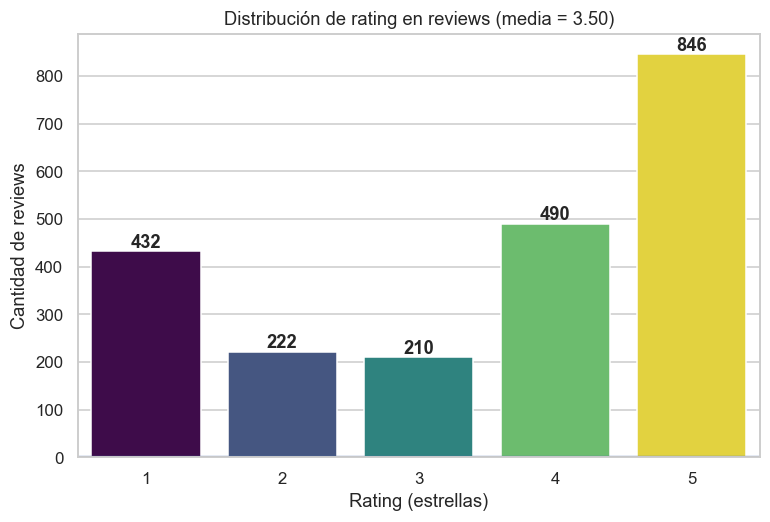

Distribución %:
rating
1    19.6 %
2    10.1 %
3     9.5 %
4    22.3 %
5    38.5 %
Name: count, dtype: object


In [8]:
conteo_rating = reviews_stores["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=conteo_rating.index, y=conteo_rating.values, palette=PALETA, hue=conteo_rating.index, legend=False)
for i, v in enumerate(conteo_rating.values):
    ax.text(i, v + 8, str(v), ha="center", fontweight="bold")
plt.axhline(0)
plt.title(f"Distribución de rating en reviews (media = {reviews_stores.rating.mean():.2f})")
plt.xlabel("Rating (estrellas)")
plt.ylabel("Cantidad de reviews")
guardar("00_dist_rating")
plt.show()

print("Distribución %:")
print((conteo_rating / conteo_rating.sum() * 100).round(1).astype(str) + " %")

**Interpretación y hallazgos:**
- La distribución es **bimodal / polarizada**: pico en **5★** y un segundo y tercer pico en **4★** y **1★**.

### 4.2. Distribución de `csat_score` (bot)

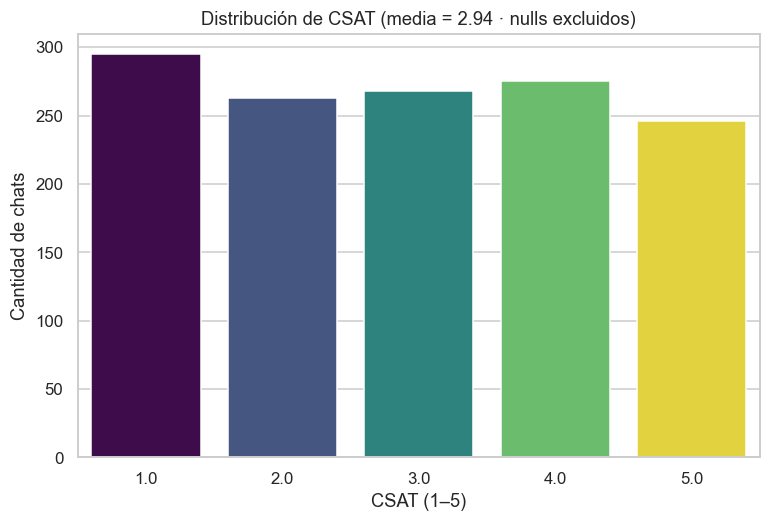

CSAT promedio (no-null): 2.94
Chats sin CSAT: 1653 de 3000 (55.1 %)


In [9]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=bot_chats["csat_score"].dropna(), palette=PALETA,
                   hue=bot_chats["csat_score"].dropna(), legend=False)
plt.title(f"Distribución de CSAT (media = {bot_chats.csat_score.mean():.2f} · nulls excluidos)")
plt.xlabel("CSAT (1–5)")
plt.ylabel("Cantidad de chats")
guardar("00_dist_csat")
plt.show()

n_null = bot_chats.csat_score.isna().sum()
print(f"CSAT promedio (no-null): {bot_chats.csat_score.mean():.2f}")
print(f"Chats sin CSAT: {n_null} de {len(bot_chats)} ({n_null/len(bot_chats)*100:.1f} %)")

**Interpretación y hallazgos:**
- El **CSAT promedio (~2.94 sobre 5) es bajo**: el bot no está dejando satisfecho al cliente promedio que sí responde.
- Más de la **mitad de los chats no tienen CSAT**. Esa no-respuesta masiva se analiza como patrón en `01_calidad` (¿es aleatoria o correlaciona con algo?).

### 4.3. Distribución de `nps_score` (clientes)

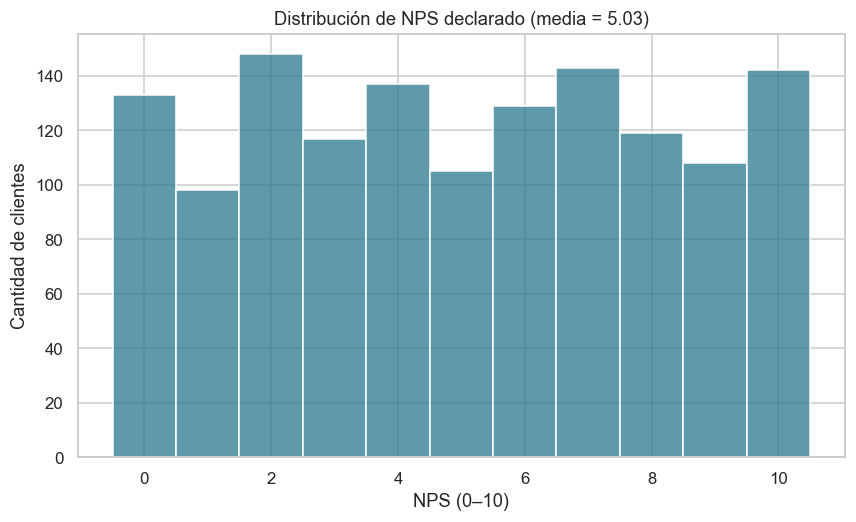

Detractores (0-6): 62.9 %  |  Pasivos (7-8): 19.0 %  |  Promotores (9-10): 18.1 %
NPS neto aproximado: -45


In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(clientes["nps_score"].dropna(), bins=11, discrete=True, color="#2a788e")
plt.title(f"Distribución de NPS declarado (media = {clientes.nps_score.mean():.2f})")
plt.xlabel("NPS (0–10)")
plt.ylabel("Cantidad de clientes")
guardar("00_dist_nps")
plt.show()

# Clasificación NPS estándar
nps = clientes["nps_score"].dropna()
detr = (nps <= 6).mean() * 100
pasi = nps.between(7, 8).mean() * 100
prom = (nps >= 9).mean() * 100
print(f"Detractores (0-6): {detr:.1f} %  |  Pasivos (7-8): {pasi:.1f} %  |  Promotores (9-10): {prom:.1f} %")
print(f"NPS neto aproximado: {prom - detr:.0f}")

**Interpretación y hallazgos:**
- NPS promedio **~5.0 sobre 10**: en la lógica NPS estándar, la base está dominada por **detractores y pasivos**, con NPS neto fuertemente negativo.
- Junto con el CSAT bajo, se dibuja un journey con **fricción de satisfacción transversal**, no aislada.

### 4.4. Variables categóricas (clientes y bot)

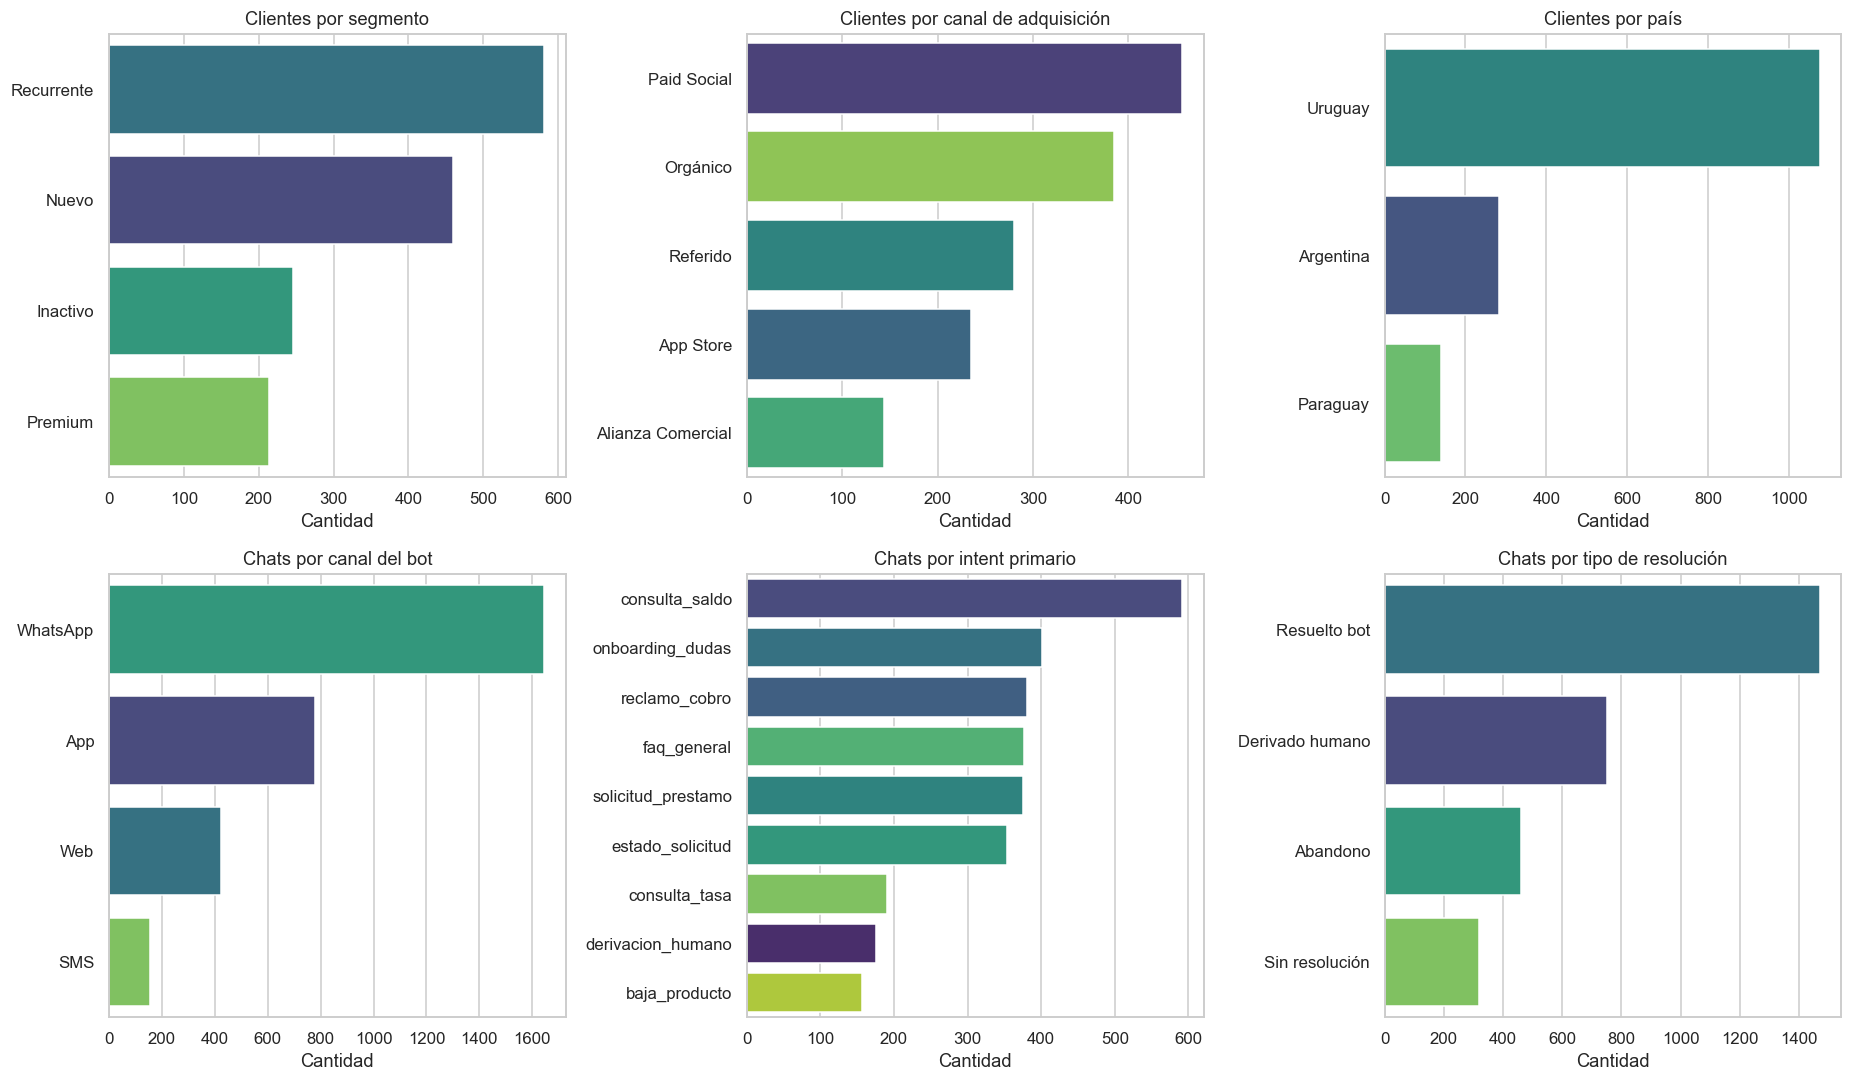

In [11]:
cat_specs = [
    (clientes, "segmento", "Clientes por segmento"),
    (clientes, "canal_adquisicion", "Clientes por canal de adquisición"),
    (clientes, "pais", "Clientes por país"),
    (bot_chats, "canal", "Chats por canal del bot"),
    (bot_chats, "intent_primario", "Chats por intent primario"),
    (bot_chats, "resolucion", "Chats por tipo de resolución"),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (df, col, titulo) in zip(axes.ravel(), cat_specs):
    orden = df[col].value_counts().index
    sns.countplot(y=df[col], order=orden, ax=ax, palette=PALETA, hue=df[col], legend=False)
    ax.set_title(titulo)
    ax.set_xlabel("Cantidad")
    ax.set_ylabel("")
plt.tight_layout()
guardar("00_categoricas")
plt.show()

**Interpretación y hallazgos:**
- **Adquisición:** *Paid Social* es el canal más grande; el negocio depende de canales pagos.
- **Geografía:** ~72% de los clientes son de **Uruguay** (mercado core), con cola en AR y PY.
- **Bot:** **WhatsApp** concentra la mayoría de los chats → es el canal crítico de atención. El intent más frecuente es `consulta_saldo`.
- **Resolución:** solo **~49% "Resuelto bot"**. La otra mitad se deriva, abandona o queda sin resolución → hay un *gap* claro de efectividad del bot a profundizar en el  `02_sql_analitico`.

### 4.5. Variables numéricas del bot (`duracion_segundos`, `mensajes_enviados`)

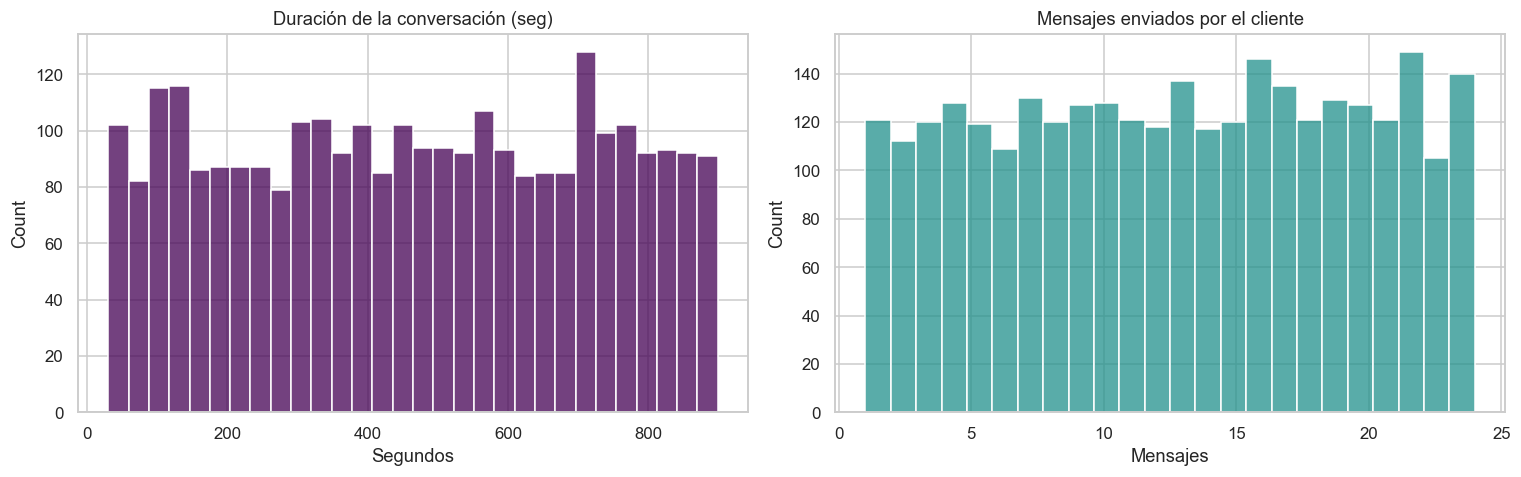

       duracion_segundos  mensajes_enviados
count             2860.0             3000.0
mean               464.0               12.7
std                252.0                6.9
min                 30.0                1.0
25%                248.0                7.0
50%                465.0               13.0
75%                689.0               19.0
max                899.0               24.0

Nulls en duracion_segundos: 140 (4.7 %)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(bot_chats["duracion_segundos"].dropna(), bins=30, ax=axes[0], color="#440154")
axes[0].set_title("Duración de la conversación (seg)")
axes[0].set_xlabel("Segundos")
sns.histplot(bot_chats["mensajes_enviados"], bins=24, ax=axes[1], color="#21918c")
axes[1].set_title("Mensajes enviados por el cliente")
axes[1].set_xlabel("Mensajes")
plt.tight_layout()
guardar("00_numericas_bot")
plt.show()

print(bot_chats[["duracion_segundos", "mensajes_enviados"]].describe().round(1))
print("\nNulls en duracion_segundos:", bot_chats.duracion_segundos.isna().sum(),
      f"({bot_chats.duracion_segundos.isna().mean()*100:.1f} %)")

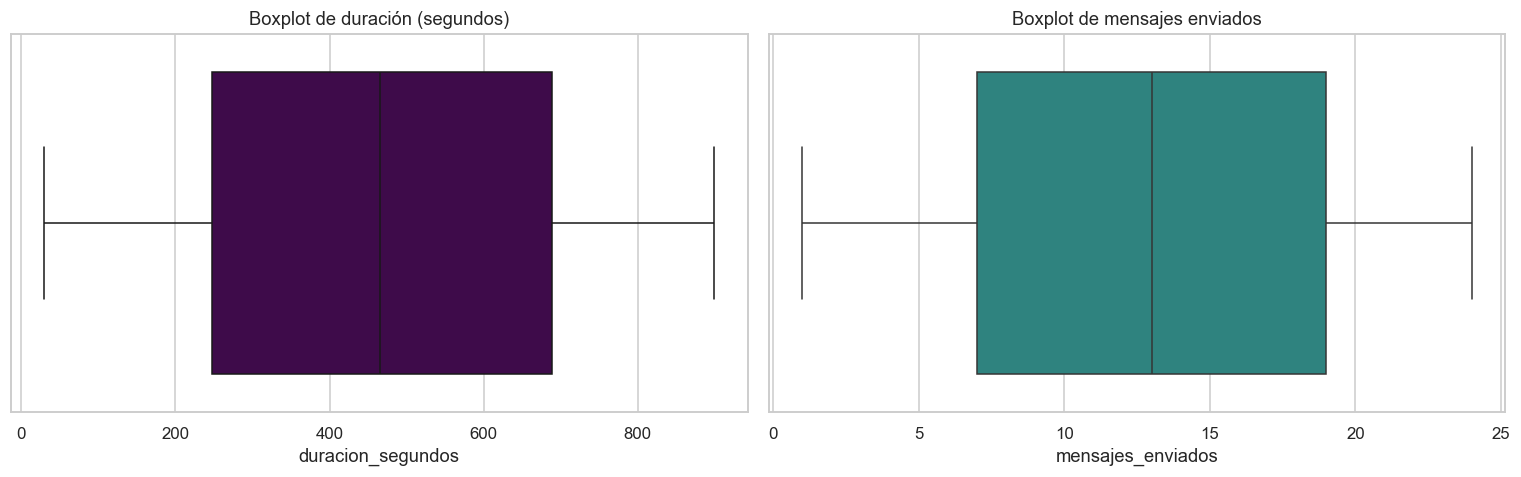

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(x=bot_chats["duracion_segundos"].dropna(), ax=axes[0], color="#440154")
axes[0].set_title("Boxplot de duración (segundos)")
sns.boxplot(x=bot_chats["mensajes_enviados"], ax=axes[1], color="#21918c")
axes[1].set_title("Boxplot de mensajes enviados")
plt.tight_layout()
plt.show()

**Interpretación y hallazgos:**
- `duracion_segundos` tiene nulls (sesiones cortadas según el diccionario) → variable a tratar con cuidado en cualquier promedio.
- Ni la duración ni los mensajes muestran una larga cola extrema: el rango está acotado, sin outliers groseros que distorsionen.

## 5. Cobertura y evolución temporal
Volumen mensual y evolución de las métricas de satisfacción.

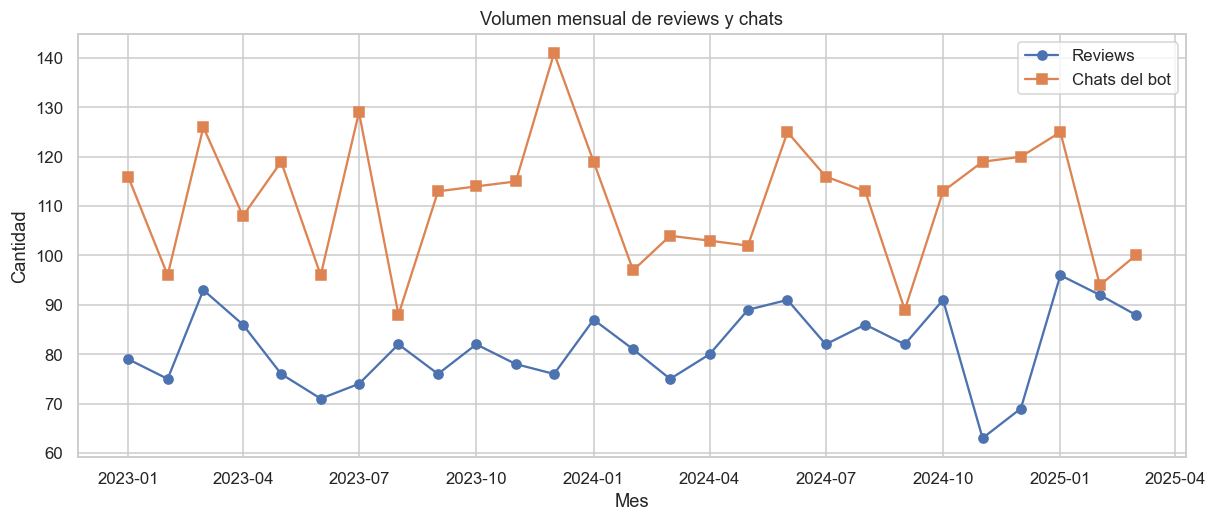

In [14]:
reviews_stores["mes"] = reviews_stores["fecha_review"].dt.to_period("M").dt.to_timestamp()
bot_chats["mes"] = bot_chats["fecha_inicio"].dt.to_period("M").dt.to_timestamp()

vol_reviews = reviews_stores.groupby("mes").size()
vol_chats   = bot_chats.groupby("mes").size()

plt.figure(figsize=(13, 5))
plt.plot(vol_reviews.index, vol_reviews.values, marker="o", label="Reviews")
plt.plot(vol_chats.index, vol_chats.values, marker="s", label="Chats del bot")
plt.title("Volumen mensual de reviews y chats")
plt.xlabel("Mes"); plt.ylabel("Cantidad"); plt.legend()
guardar("00_volumen_mensual")
plt.show()

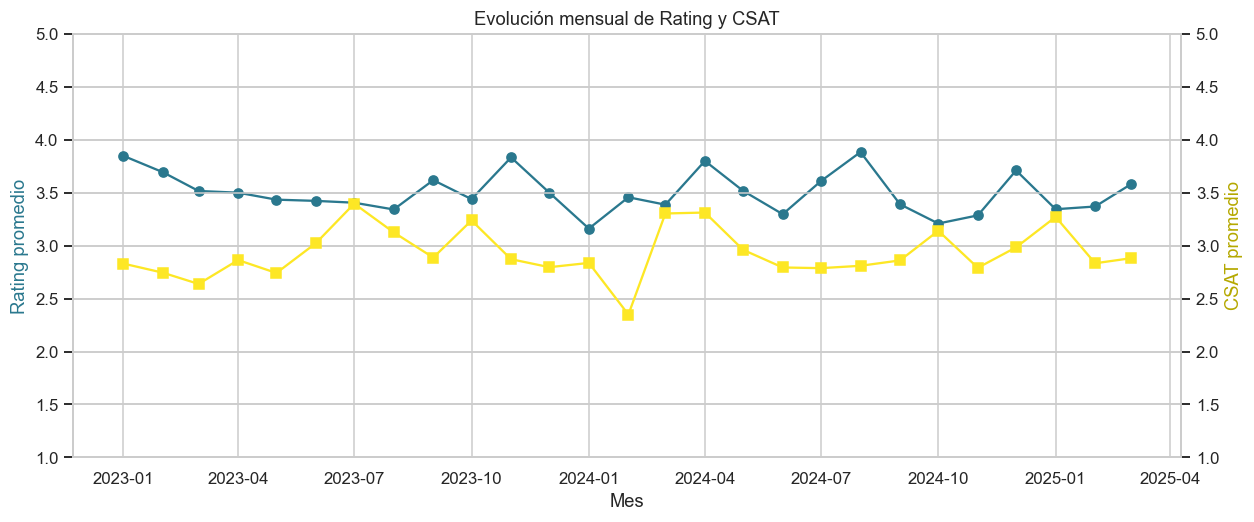

In [15]:
rating_mes = reviews_stores.groupby("mes")["rating"].mean()
csat_mes   = bot_chats.groupby("mes")["csat_score"].mean()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(rating_mes.index, rating_mes.values, marker="o", color="#2a788e", label="Rating prom (1-5)")
ax1.set_ylabel("Rating promedio", color="#2a788e")
ax1.set_ylim(1, 5)
ax2 = ax1.twinx()
ax2.plot(csat_mes.index, csat_mes.values, marker="s", color="#fde725", label="CSAT prom (1-5)")
ax2.set_ylabel("CSAT promedio", color="#b5a800")
ax2.set_ylim(1, 5)
ax1.set_title("Evolución mensual de Rating y CSAT")
ax1.set_xlabel("Mes")
guardar("00_evolucion_satisfaccion")
plt.show()

## 6. Exploración bivariante

Relaciones que orientan el análisis posterior (todavía descriptivas, no son aún las queries de negocio de `sql_analitico_02`).

### 6.1. Rating por producto, store y versión de app

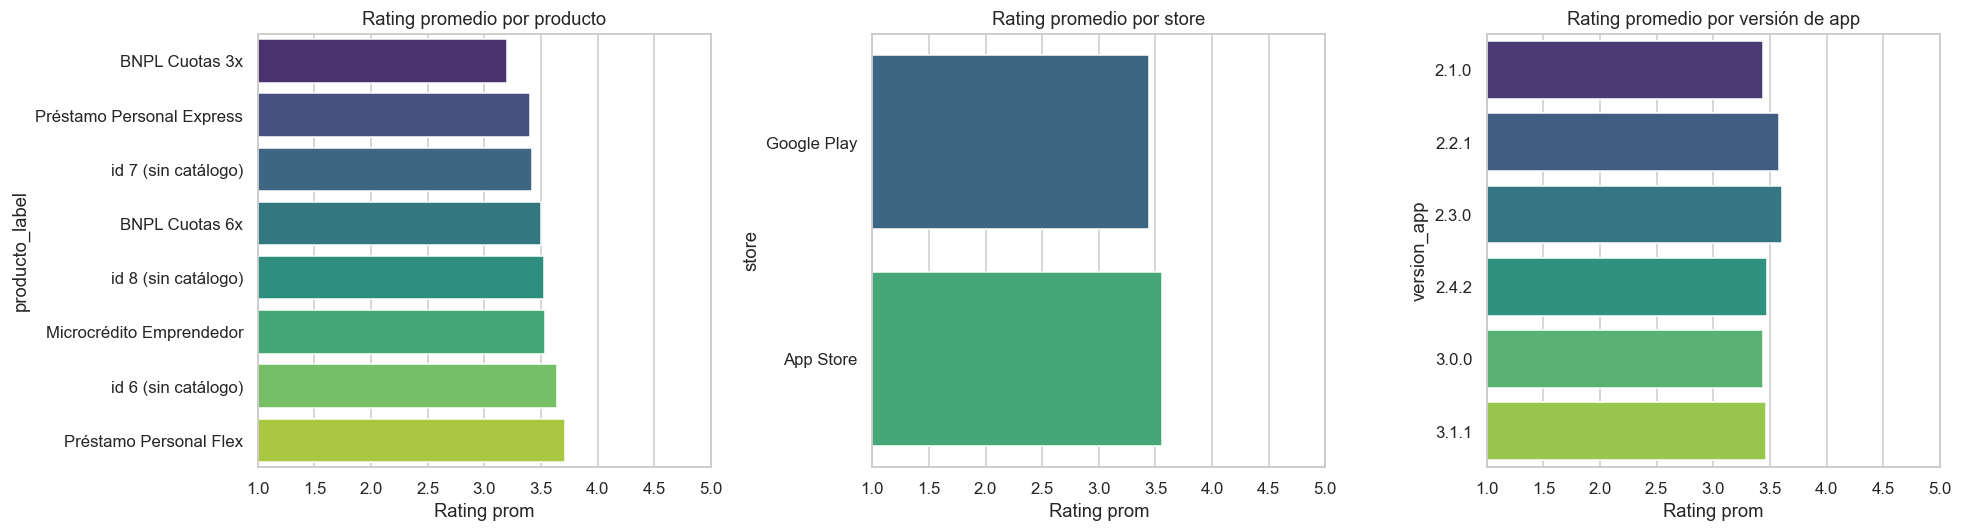

In [17]:
# Traemos el nombre del producto; marcamos los id sin entrada en el catálogo
rev_prod = reviews_stores.merge(productos[["id_producto", "nombre_producto"]], on="id_producto", how="left")
rev_prod["producto_label"] = rev_prod["nombre_producto"].fillna(
    "id " + rev_prod["id_producto"].astype(str) + " (sin catálogo)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

r_prod = rev_prod.groupby("producto_label")["rating"].mean().sort_values()
sns.barplot(x=r_prod.values, y=r_prod.index, ax=axes[0], palette=PALETA, hue=r_prod.index, legend=False)
axes[0].set_title("Rating promedio por producto"); axes[0].set_xlabel("Rating prom"); axes[0].set_xlim(1, 5)

r_store = reviews_stores.groupby("store")["rating"].mean().sort_values()
sns.barplot(x=r_store.values, y=r_store.index, ax=axes[1], palette=PALETA, hue=r_store.index, legend=False)
axes[1].set_title("Rating promedio por store"); axes[1].set_xlabel("Rating prom"); axes[1].set_xlim(1, 5)

r_ver = reviews_stores.groupby("version_app")["rating"].mean().sort_index()
sns.barplot(x=r_ver.values, y=r_ver.index, ax=axes[2], palette=PALETA, hue=r_ver.index, legend=False)
axes[2].set_title("Rating promedio por versión de app"); axes[2].set_xlabel("Rating prom"); axes[2].set_xlim(1, 5)

plt.tight_layout()
guardar("00_rating_bivariante")
plt.show()

**Interpretación y hallazgos:**
- Aparecen `id_producto` **sin entrada en el catálogo** (`productos` solo tiene 5 IDs) → primera señal de un problema de **integridad referencial** que se cuantifica en `01_calidad`.
- Conviene fijarse si alguna **versión de app** concentra rating bajo (posible release problemática) — candidato a insight.

### 6.2. CSAT por intent, resolución y canal del bot

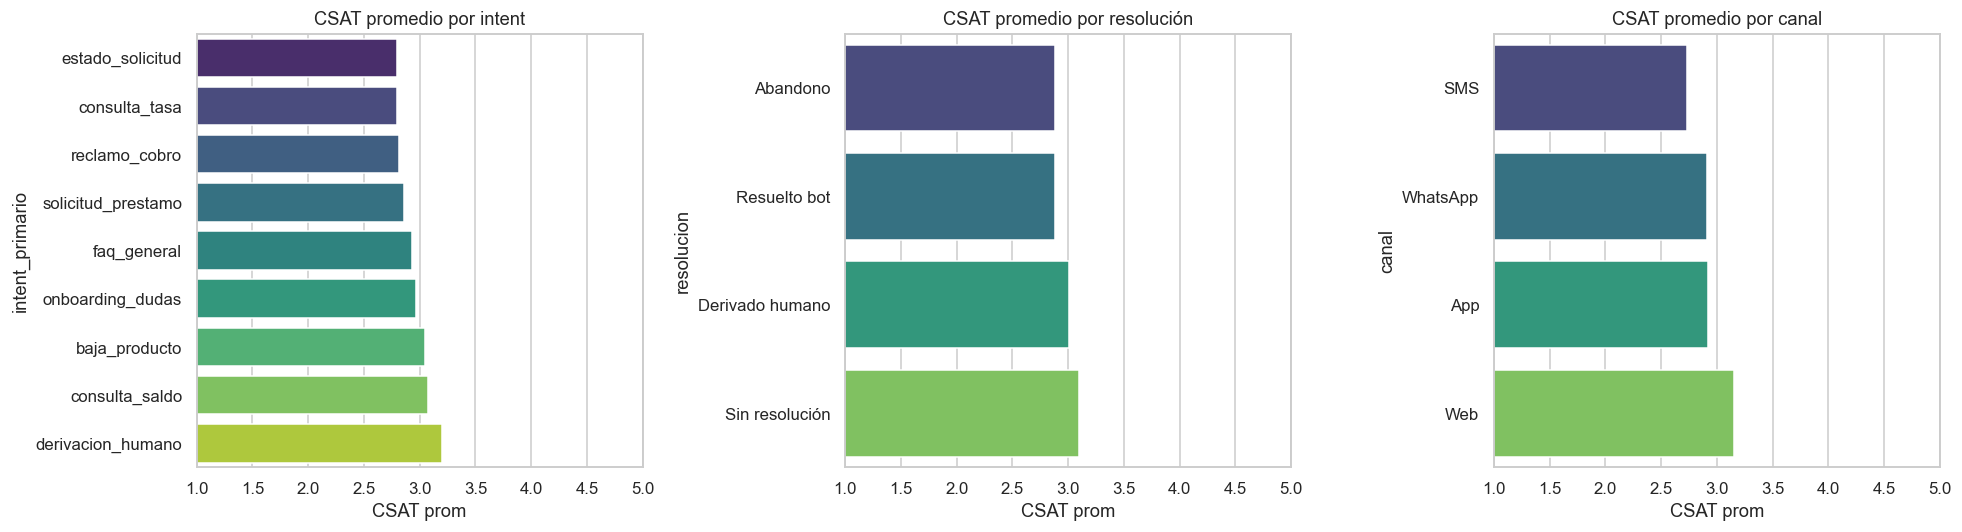

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c_intent = bot_chats.groupby("intent_primario")["csat_score"].mean().sort_values()
sns.barplot(x=c_intent.values, y=c_intent.index, ax=axes[0], palette=PALETA, hue=c_intent.index, legend=False)
axes[0].set_title("CSAT promedio por intent"); axes[0].set_xlabel("CSAT prom"); axes[0].set_xlim(1, 5)

c_res = bot_chats.groupby("resolucion")["csat_score"].mean().sort_values()
sns.barplot(x=c_res.values, y=c_res.index, ax=axes[1], palette=PALETA, hue=c_res.index, legend=False)
axes[1].set_title("CSAT promedio por resolución"); axes[1].set_xlabel("CSAT prom"); axes[1].set_xlim(1, 5)

c_can = bot_chats.groupby("canal")["csat_score"].mean().sort_values()
sns.barplot(x=c_can.values, y=c_can.index, ax=axes[2], palette=PALETA, hue=c_can.index, legend=False)
axes[2].set_title("CSAT promedio por canal"); axes[2].set_xlabel("CSAT prom"); axes[2].set_xlim(1, 5)

plt.tight_layout()
guardar("00_csat_bivariante")
plt.show()

**Interpretación y hallazgos:**
- Buscamos qué **intents** y qué **canales** arrastran el CSAT hacia abajo → son los puntos del journey donde el bot frustra al cliente.

### 6.3. Escalado a humano por intent · NPS por segmento

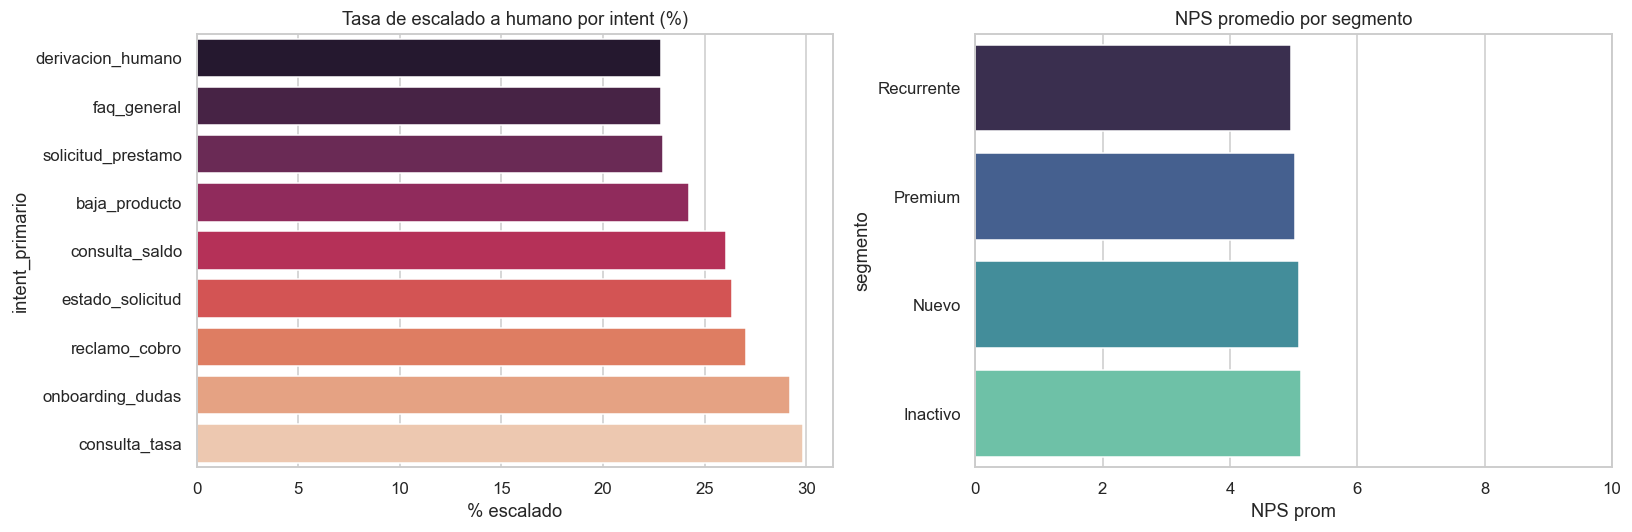

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

esc = bot_chats.groupby("intent_primario")["escalado_humano"].mean().mul(100).sort_values()
sns.barplot(x=esc.values, y=esc.index, ax=axes[0], palette="rocket", hue=esc.index, legend=False)
axes[0].set_title("Tasa de escalado a humano por intent (%)"); axes[0].set_xlabel("% escalado")

nps_seg = clientes.groupby("segmento")["nps_score"].mean().sort_values()
sns.barplot(x=nps_seg.values, y=nps_seg.index, ax=axes[1], palette="mako", hue=nps_seg.index, legend=False)
axes[1].set_title("NPS promedio por segmento"); axes[1].set_xlabel("NPS prom"); axes[1].set_xlim(0, 10)

plt.tight_layout()
guardar("00_escalado_nps")
plt.show()

**Interpretación y hallazgos:**
- Los intents con **mayor tasa de escalado** son los *gaps* del bot: tareas que hoy no resuelve solo. Se formaliza en `02_sql_analitico` (query b).
- El NPS por segmento no muestra una concentracion en ningún segmento específico.

## 7. Granularidad y unidad de análisis

In [20]:
rev_x_cli = reviews_stores["id_cliente"].value_counts()
chat_x_cli = bot_chats["id_cliente"].value_counts()

print("REVIEWS")
print(f"  Reviews por cliente -> máx: {rev_x_cli.max()} | promedio: {rev_x_cli.mean():.2f}")
print(f"  Clientes con más de 1 review: {(rev_x_cli > 1).sum()}")
print(f"  Clientes que dejaron al menos 1 review: {reviews_stores.id_cliente.nunique()} de {len(clientes)} "
      f"({reviews_stores.id_cliente.nunique()/len(clientes)*100:.0f} %)")

print("\nBOT CHATS")
print(f"  Chats por cliente -> máx: {chat_x_cli.max()} | promedio: {chat_x_cli.mean():.2f}")
print(f"  Clientes que usaron el bot: {bot_chats.id_cliente.nunique()} de {len(clientes)} "
      f"({bot_chats.id_cliente.nunique()/len(clientes)*100:.0f} %)")

REVIEWS
  Reviews por cliente -> máx: 6 | promedio: 1.97
  Clientes con más de 1 review: 664
  Clientes que dejaron al menos 1 review: 1116 de 1500 (74 %)

BOT CHATS
  Chats por cliente -> máx: 9 | promedio: 2.33
  Clientes que usaron el bot: 1290 de 1500 (86 %)


**Interpretación y hallazgos:**
- **Un cliente puede tener varias reviews** (hasta 6) y **varios chats** (promedio ~2.3). El dataset **no es** "1 fila = 1 cliente" en reviews/bot → cualquier KPI a nivel cliente exige **deduplicar o agregar** primero (clave para `02_sql_analitico`).
- La cobertura es parcial (no todos los clientes dejan review ni usan el bot): los promedios de satisfacción describen **a quienes interactuaron**, no a toda la base. Supuesto a documentar.

## 8. Síntesis de hallazgos exploratorios

1. **CSAT ~2.9/5** y **NPS ~5/10**. El problema de satisfacción no está aislado.
2. **Bot poco resolutivo:** solo ~49% de chats "Resuelto bot"; **WhatsApp** es el canal dominante a optimizar.
3. **Señal de integridad referencial:** hay `id_producto` en reviews que no existen en el catálogo → a cuantificar en `01_calidad`.
4. **Restricción de modelado:** `csat` no se puede abrir por `version_app` (no existe esa columna en `bot_chats`).
5. **Granularidad multi-evento:** varios registros por cliente → deduplicar/agregar antes de cualquier métrica por cliente.

### Próximos pasos
- `01_calidad_datos`: cuantificar nulls (patrón de `csat`/`nps`), duplicados e integridad referencial (los productos fantasma).
- `02_sql_analitico`: responder las preguntas de negocio (correlación canal–rating, tasa de escalado por intent, evolución mensual) y derivar el **insight accionable**.